# Part 3 – Merge by ubigeo and analysis
**Group 2 · Season 2023 (January 1 to May 31)**

Research question: Does the State declare emergencies where it rains the most?

In [1]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

# Render every chart twice: the interactive version for Jupyter and a static
# PNG, so the charts are also visible in GitHub's notebook viewer.
pio.renderers.default = "plotly_mimetype+png"


## 1. Create the ubigeo table

We create a table with the official department-level ubigeo codes from INEI (25 departments, including Callao). Each ubigeo is written between quotes so it is stored as **text** and keeps the leading zero ("01", not 1).

Source: official department-level ubigeo codes from INEI, as provided in the assignment instructions.

In [2]:
# Official INEI department codes (from the assignment instructions)
ubigeos = pd.DataFrame({
    "ubigeo": ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10",
               "11", "12", "13", "14", "15", "16", "17", "18", "19", "20",
               "21", "22", "23", "24", "25"],
    "departamento": ["Amazonas", "Áncash", "Apurímac", "Arequipa", "Ayacucho",
                     "Cajamarca", "Callao", "Cusco", "Huancavelica", "Huánuco",
                     "Ica", "Junín", "La Libertad", "Lambayeque", "Lima",
                     "Loreto", "Madre de Dios", "Moquegua", "Pasco", "Piura",
                     "Puno", "San Martín", "Tacna", "Tumbes", "Ucayali"]
})

ubigeos.to_csv("datos/ubigeos.csv", index=False, encoding="utf-8-sig")

print(ubigeos.shape)
ubigeos.head()

(25, 2)


,ubigeo,departamento
0,01,Amazonas
1,02,Áncash
2,03,Apurímac
3,04,Arequipa
4,05,Ayacucho


## 2. Reading the ubigeo file in two ways

We read `ubigeos.csv` twice: first with a normal `pd.read_csv`, and then telling pandas that the `ubigeo` column is text (`dtype={"ubigeo": str}`).

In [3]:
# Normal reading
ubigeos_normal = pd.read_csv("datos/ubigeos.csv", encoding="utf-8-sig")

# Reading ubigeo as text
ubigeos_texto = pd.read_csv("datos/ubigeos.csv", encoding="utf-8-sig", dtype={"ubigeo": str})

# Type of the ubigeo column in each case
print("Normal reading:", ubigeos_normal["ubigeo"].dtype)
print("Reading as text:", ubigeos_texto["ubigeo"].dtype)

# Side by side comparison
comparacion = pd.DataFrame({
    "departamento": ubigeos_texto["departamento"],
    "ubigeo_normal": ubigeos_normal["ubigeo"],
    "ubigeo_texto": ubigeos_texto["ubigeo"]
})
comparacion.head(10)

Normal reading: int64
Reading as text: object


,departamento,ubigeo_normal,ubigeo_texto
0,Amazonas,1,01
1,Áncash,2,02
2,Apurímac,3,03
3,Arequipa,4,04
4,Ayacucho,5,05
5,Cajamarca,6,06
6,Callao,7,07
7,Cusco,8,08
8,Huancavelica,9,09
9,Huánuco,10,10


In [4]:
# Test: does "01" match 1?
print(ubigeos_texto["ubigeo"][0] == ubigeos_normal["ubigeo"][0])

# Test: even converting the number to text, "1" is not "01"
print(ubigeos_texto["ubigeo"][0] == str(ubigeos_normal["ubigeo"][0]))

False
False


### Why does it matter?

With a normal `pd.read_csv`, pandas guesses that `ubigeo` is a number (`int64`) and **drops the leading zero**: Amazonas goes from `01` to `1`. When we use `dtype={"ubigeo": str}`, the column is read as text and keeps its original 2 digits.

This matters for two reasons:

1. **The ubigeo is a code, not a quantity.** It works like an ID (like a DNI number): it makes no sense to add or average ubigeos. It must keep its official format (2 digits for departments, 6 for districts, e.g. Chachapoyas is `010101`, not `10101`).
2. **The merge would fail.** In step 5 we merge the tables by `ubigeo`. As the test above shows, `"01"` and `1` are not equal for Python, and even converting the number back to text gives `"1"`, not `"01"`. If one table has the code as text and the other as a number, departments would not match and would be lost or left empty.

That is why we always read the ubigeo with `dtype={"ubigeo": str}`.

## 3. Adding the ubigeo to the decrees and rainfall tables

We load the two tables created in Parts 1 and 2 and check how the department names are written, since we will use them to add the ubigeo.

In [5]:
decretos = pd.read_csv("datos/decretos_por_departamento.csv", encoding="utf-8-sig")
lluvias = pd.read_csv("datos/lluvias_por_departamento.csv", encoding="utf-8-sig")

print("Decrees:", decretos.shape)
print("Rainfall:", lluvias.shape)

print("\nDepartment names in decrees:")
print(decretos["departamento"].tolist())

print("\nDepartment names in rainfall:")
print(lluvias["departamento"].tolist())

Decrees: (25, 3)
Rainfall: (25, 6)

Department names in decrees:
['Amazonas', 'Ancash', 'Apurimac', 'Arequipa', 'Ayacucho', 'Cajamarca', 'Callao', 'Cusco', 'Huancavelica', 'Huanuco', 'Ica', 'Junin', 'La Libertad', 'Lambayeque', 'Lima', 'Loreto', 'Madre de Dios', 'Moquegua', 'Pasco', 'Piura', 'Puno', 'San Martin', 'Tacna', 'Tumbes', 'Ucayali']

Department names in rainfall:
['Amazonas', 'Ancash', 'Apurimac', 'Arequipa', 'Ayacucho', 'Cajamarca', 'Cusco', 'Huancavelica', 'Huanuco', 'Ica', 'Junin', 'La Libertad', 'Lambayeque', 'Lima', 'Loreto', 'Madre de Dios', 'Moquegua', 'Pasco', 'Piura', 'Puno', 'San Martin', 'Tacna', 'Tumbes', 'Ucayali', 'Callao']


In [6]:
# First try: add the ubigeo by matching the department name as it is
decretos_ubigeo = decretos.merge(ubigeos_texto, on="departamento", how="left")
lluvias_ubigeo = lluvias.merge(ubigeos_texto, on="departamento", how="left")

# Departments that did not find their ubigeo
print("Decrees without ubigeo:")
print(decretos_ubigeo[decretos_ubigeo["ubigeo"].isna()]["departamento"].tolist())

print("\nRainfall without ubigeo:")
print(lluvias_ubigeo[lluvias_ubigeo["ubigeo"].isna()]["departamento"].tolist())

Decrees without ubigeo:
['Ancash', 'Apurimac', 'Huanuco', 'Junin', 'San Martin']

Rainfall without ubigeo:
['Ancash', 'Apurimac', 'Huanuco', 'Junin', 'San Martin']


## 4. Fixing department names without ubigeo

The first merge shows that 5 departments did not find their ubigeo in either table: Ancash, Apurimac, Huanuco, Junin and San Martin. The reason is that Parts 1 and 2 wrote the names **without accents**, while the official INEI table uses accents (Áncash, Apurímac, Huánuco, Junín, San Martín). For Python, "Ancash" and "Áncash" are different texts.

We fix them with a dictionary that replaces each name with its official INEI spelling, and then we check again.

In [7]:
# Dictionary: name as written in Parts 1 and 2 -> official INEI name
correcciones = {
    "Ancash": "Áncash",
    "Apurimac": "Apurímac",
    "Huanuco": "Huánuco",
    "Junin": "Junín",
    "San Martin": "San Martín"
}

decretos["departamento"] = decretos["departamento"].replace(correcciones)
lluvias["departamento"] = lluvias["departamento"].replace(correcciones)

# Second try: add the ubigeo again
decretos_ubigeo = decretos.merge(ubigeos_texto, on="departamento", how="left")
lluvias_ubigeo = lluvias.merge(ubigeos_texto, on="departamento", how="left")

print("Decrees without ubigeo:")
print(decretos_ubigeo[decretos_ubigeo["ubigeo"].isna()]["departamento"].tolist())

print("\nRainfall without ubigeo:")
print(lluvias_ubigeo[lluvias_ubigeo["ubigeo"].isna()]["departamento"].tolist())

Decrees without ubigeo:
[]

Rainfall without ubigeo:
[]


## 5. Merging decrees and rainfall by ubigeo

We join the two tables using the `ubigeo` code, not the department name. The base is the official table of 25 ubigeos: we add the decrees and the rainfall to it with a left join, so every department stays in the result even if it is missing from one of the tables. Before merging we drop `departamento` from the decrees and rainfall tables, so the name plays no role in the join and comes only from the official INEI table.

`validate="one_to_one"` stops the merge with an error if a ubigeo appears twice in a table, instead of silently duplicating rows. A department missing from the decrees table had no decree, so its `declaratorias` and `prorrogas` are filled with 0.

In [8]:
tabla_final = (
    ubigeos_texto
    .merge(decretos_ubigeo.drop(columns="departamento"), on="ubigeo", how="left", validate="one_to_one")
    .merge(lluvias_ubigeo.drop(columns="departamento"), on="ubigeo", how="left", validate="one_to_one")
)

# A department missing from the decrees table had no decree: it counts as 0
tabla_final[["declaratorias", "prorrogas"]] = tabla_final[["declaratorias", "prorrogas"]].fillna(0).astype(int)

tabla_final = tabla_final[["ubigeo", "departamento", "declaratorias", "prorrogas", "lluvia_total_mm",
                           "dias_lluvia_fuerte", "capital", "latitud", "longitud"]]
tabla_final

,ubigeo,departamento,declaratorias,prorrogas,lluvia_total_mm,dias_lluvia_fuerte,capital,latitud,longitud
0,01,Amazonas,3,1,414.6,3,Chachapoyas,-6.23169,-77.86903
1,02,Áncash,6,1,1145.8,9,Huaraz,-9.52614,-77.52869
2,03,Apurímac,1,0,726.2,3,Abancay,-13.63426,-72.88380
3,04,Arequipa,4,0,362.0,1,Arequipa,-16.39899,-71.53747
4,05,Ayacucho,5,1,498.4,2,Ayacucho,-13.16380,-74.22345
5,06,Cajamarca,4,0,796.6,0,Cajamarca,-7.16378,-78.50027
6,07,Callao,1,0,55.5,0,Callao,-12.05162,-77.13452
7,08,Cusco,2,0,714.0,1,Cusco,-13.53188,-71.96701
8,09,Huancavelica,3,0,817.8,3,Huancavelica,-12.78691,-74.97298
9,10,Huánuco,4,0,524.3,2,Huánuco,-9.92882,-76.23989


## 6. Verifying the final table

The final table must have exactly 25 rows, one per department. A department with no declaration has to appear with `0`, not disappear: Madre de Dios had no rainfall declaration this season, so it is the row to watch.

We also check that the merge did not lose data: the total number of declarations must be the same before and after the merge, and every department must have its rainfall. If any check fails, the cell stops with an error instead of only printing a warning.

In [9]:
filas = len(tabla_final)
print(f"Rows in the final table: {filas} (expected: 25)")

print("Departments with 0 declarations:",
      tabla_final[tabla_final["declaratorias"] == 0]["departamento"].tolist())

print("\nDeclarations before the merge:", decretos["declaratorias"].sum())
print("Declarations after the merge: ", tabla_final["declaratorias"].sum())
print("Departments without rainfall:",
      tabla_final[tabla_final["lluvia_total_mm"].isna()]["departamento"].tolist())

if filas != 25:
    raise RuntimeError(f"The final table has {filas} rows instead of 25.")
if tabla_final["declaratorias"].sum() != decretos["declaratorias"].sum():
    raise RuntimeError("Some declarations were lost in the merge.")
if tabla_final["lluvia_total_mm"].isna().any():
    raise RuntimeError("Some departments have no rainfall data.")

Rows in the final table: 25 (expected: 25)
Departments with 0 declarations: ['Madre de Dios']

Declarations before the merge: 72
Declarations after the merge:  72
Departments without rainfall: []


## 7. Saving the final table

We save the table as `datos/tabla_final.csv`. A CSV file has no column types, so the ubigeo keeps its two digits only if it is still text when it is written. We check that before saving, and then read the file back with `dtype={"ubigeo": str}` to confirm it was stored as `"01"` and not `"1"`. Anyone who reads this file later must also use `dtype={"ubigeo": str}`, as shown in step 2.

In [10]:
if not tabla_final["ubigeo"].str.len().eq(2).all():
    raise RuntimeError("Some ubigeos do not have 2 digits.")

tabla_final.to_csv("datos/tabla_final.csv", index=False, encoding="utf-8-sig")

# Read the file back to confirm the leading zero was saved
tabla_guardada = pd.read_csv("datos/tabla_final.csv", encoding="utf-8-sig", dtype={"ubigeo": str})

print("Saved:", tabla_guardada.shape)
print("First ubigeos:", tabla_guardada["ubigeo"].head().tolist())
print("All ubigeos have 2 digits:", tabla_guardada["ubigeo"].str.len().eq(2).all())

Saved: (25, 9)
First ubigeos: ['01', '02', '03', '04', '05']
All ubigeos have 2 digits: True


## 8. Charts

**Scatter plot.** Each point is a department, with the total rainfall of the season (`lluvia_total_mm`) on the X axis and the number of declarations on the Y axis. If the State declared emergencies where it rains the most, the points would rise from left to right. Many departments have the same number of declarations, so their names would overlap on the same row. To keep all 25 names readable, we alternate each label above and below its point.

**Bar chart.** The 10 departments with the most declarations. The cut at 10 falls inside a tie: positions 9 to 14 are six departments with 3 declarations each, so only the first two of them appear, by row order.

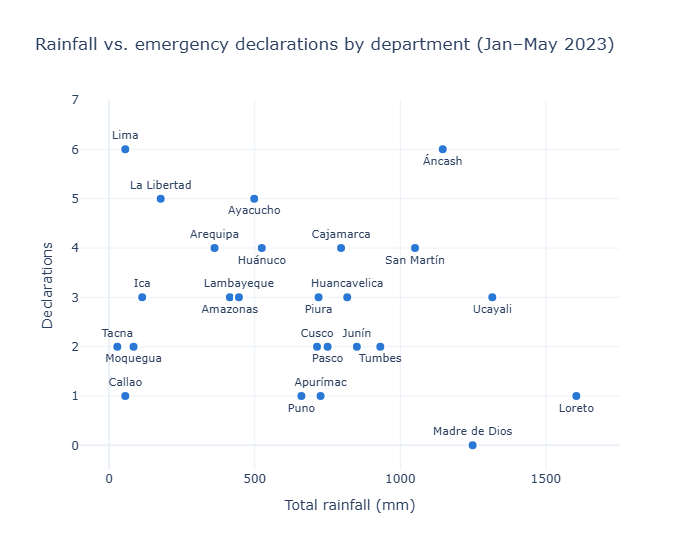

In [11]:
tabla_grafico = tabla_final.sort_values("lluvia_total_mm")

# Departments with the same number of declarations share a row: alternate their labels above and below the point
tabla_grafico["posicion_texto"] = (
    tabla_grafico.groupby("declaratorias").cumcount().mod(2).map({0: "top center", 1: "bottom center"})
)

fig_dispersion = px.scatter(
    tabla_grafico,
    x="lluvia_total_mm",
    y="declaratorias",
    text="departamento",
    hover_data=["ubigeo", "dias_lluvia_fuerte"],
    title="Rainfall vs. emergency declarations by department (Jan–May 2023)",
    labels={"lluvia_total_mm": "Total rainfall (mm)", "declaratorias": "Declarations",
            "departamento": "Department", "dias_lluvia_fuerte": "Heavy rain days"},
    template="plotly_white",
    color_discrete_sequence=["#2a78d6"],
    # Extra margin on the axes so the labels at the edges are not cut off
    range_x=[-100, tabla_final["lluvia_total_mm"].max() + 150],
    range_y=[-0.5, tabla_final["declaratorias"].max() + 1],
    height=550,
)
fig_dispersion.update_traces(
    textposition=tabla_grafico["posicion_texto"].tolist(),
    textfont_size=11,
    marker=dict(size=10, line=dict(width=2, color="white")),
)
fig_dispersion.update_yaxes(dtick=1)
fig_dispersion.show()

Departments in the chart: 10
Declarations of the 10th place: 3


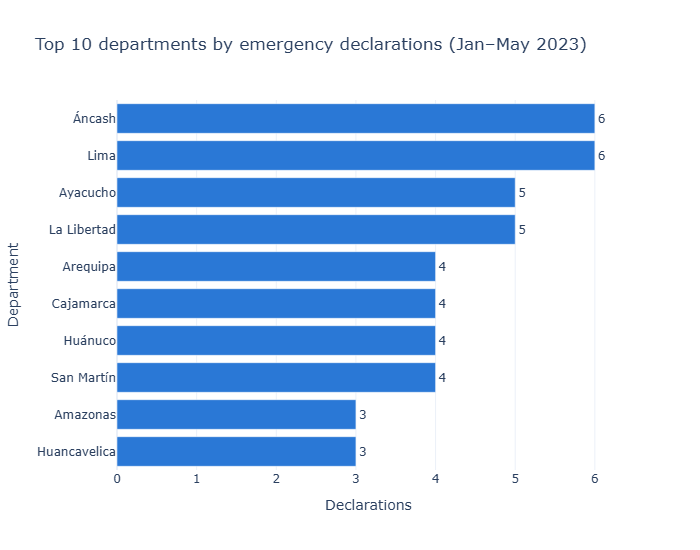

In [12]:
top_declaratorias = tabla_final.nlargest(10, "declaratorias")

print(f"Departments in the chart: {len(top_declaratorias)}")
print("Declarations of the 10th place:", top_declaratorias["declaratorias"].iloc[9])

fig_barras = px.bar(
    top_declaratorias,
    x="declaratorias",
    y="departamento",
    orientation="h",
    text="declaratorias",
    title="Top 10 departments by emergency declarations (Jan–May 2023)",
    labels={"declaratorias": "Declarations", "departamento": "Department"},
    template="plotly_white",
    color_discrete_sequence=["#2a78d6"],
    height=550,
)
fig_barras.update_traces(textposition="outside", cliponaxis=False)
fig_barras.update_yaxes(autorange="reversed")
fig_barras.show()

## 9. Data for the analysis questions

The next two cells print the data needed to answer the analysis questions:

- The 3 departments with the most declarations and the 3 with the most rainfall. Here we also use `keep="all"`, so a tie at 3rd place shows every tied department.
- The share of declarations by imminent hazard (*peligro inminente*) versus damage impact (*impacto de daños*).

For the share we go back to `datos/decretos_lluvias.csv` from Part 1, because the per-department table does not have the reason (`motivo`). Each decree is counted once, and we keep only declarations (`tipo == "declara"`), not extensions. As documented in Part 1, the national emergency for Cyclone Yaku (DS 043-2023-PCM) was declared *"por desastre de gran magnitud"*, which is neither of the two reasons. It appears as `otro`, so the three percentages add up to 100%.

In [13]:
columnas = ["ubigeo", "departamento", "declaratorias", "lluvia_total_mm"]

print("Top 3 departments by declarations:")
print(tabla_final.nlargest(3, "declaratorias", keep="all")[columnas].to_string(index=False))

print("\nTop 3 departments by total rainfall:")
print(tabla_final.nlargest(3, "lluvia_total_mm", keep="all")[columnas].to_string(index=False))

Top 3 departments by declarations:
ubigeo departamento  declaratorias  lluvia_total_mm
    02       Áncash              6           1145.8
    15         Lima              6             55.5
    05     Ayacucho              5            498.4
    13  La Libertad              5            177.2

Top 3 departments by total rainfall:
ubigeo  departamento  declaratorias  lluvia_total_mm
    16        Loreto              1           1604.6
    25       Ucayali              3           1316.0
    17 Madre de Dios              0           1248.4


In [14]:
decretos_lluvias = pd.read_csv("datos/decretos_lluvias.csv", encoding="utf-8-sig")
declaratorias_lluvias = decretos_lluvias[decretos_lluvias["tipo"] == "declara"]

motivos = declaratorias_lluvias["motivo"].value_counts().to_frame("decretos")
motivos["porcentaje"] = (motivos["decretos"] / motivos["decretos"].sum() * 100).round(1)

print("Rainfall declarations (tipo == 'declara'):", len(declaratorias_lluvias))
print(motivos)

Rainfall declarations (tipo == 'declara'): 17
                   decretos  porcentaje
motivo                                 
impacto de daños         13        76.5
peligro inminente         3        17.6
otro                      1         5.9


### Question 1

**Question:** Which 3 departments had the most declarations? Do they match the 3 where it rained the most?

**Answer:** Top 3 by declarations: Áncash (6), Lima (6), and a tie for third between Ayacucho (5) and La Libertad (5). Top 3 by rainfall: Loreto (1,604.6 mm), Ucayali (1,316.0 mm), Madre de Dios (1,248.4 mm). They do not match — the two groups share no department. Loreto, the rainiest, had only 1 declaration; Madre de Dios had none.

### Question 2

**Question:** Are there departments with a lot of rain and few or no declarations, or the other way around? Give at least two possible reasons.

**Answer:** Yes, in both directions. High rainfall, few declarations: Madre de Dios (1,248 mm, 0), Loreto (1,605 mm, 1), Ucayali (1,316 mm, 3). Low rainfall, many declarations: Lima (55.5 mm, 6), La Libertad (177 mm, 5), Ica (114 mm, 3).

Possible reasons:

- Rainfall is measured only at the capital city. Lima's capital is coastal desert, but the department's Andean provinces (Huarochirí, Canta, Yauyos) get rain that triggers landslides. The capital does not represent the department.

- What matters is the anomaly, not the absolute level. In the Amazon, 1,500 mm over five months is normal and infrastructure is adapted to it. The same figure on the northern coast would be an extreme event.

- A declaration is an administrative decision, not a physical one. It depends on exposure, vulnerability (housing in ravines, no drainage where it "never rains"), and the local government's capacity to file for it.

### Question 3

**Question:** What percentage of declarations was for imminent hazard (before the damage) and what percentage for damage impact (after)? What does that say about risk management in your season?

**Answer:** Of 17 rainfall declarations: 76.5% for damage impact (13 decrees), 17.6% for imminent hazard (3), and 5.9% classified as "other" (DS 043-2023-PCM, the national emergency for Cyclone Yaku, declared "por desastre de gran magnitud"). Comparing only the two categories the question asks about, the split is 81.25% vs 18.75%.

This points to a reactive risk management: four out of five declarations arrive after the damage has occurred. It runs against the preventive approach of Law 29664 (SINAGERD), which prioritizes prospective and corrective management over reactive response, and it means public spending concentrates on rehabilitation rather than prevention.

### Question 4

**Question:** Mention at least three limitations of this analysis.

**Answer:** 

- One measurement point per department. The capital's rainfall is assigned to the whole territory, which misrepresents departments spanning several ecological tiers (Lima, Áncash, Cusco). Lima and Callao return exactly 55.5 mm because their capitals are ~12 km apart and fall in the same model cell.

- Mismatched unit of analysis. Declarations are issued at the district level but aggregated by department, so a decree covering 2 districts weighs the same as one covering 60.

- No baseline. We compare absolute rainfall rather than deviation from the historical average, which is what actually signals an emergency.

- Reanalysis data. Open-Meteo returns model output, not SENAMHI station measurements, so accuracy drops where station coverage is thin.

- A single season, and an atypical one because of Cyclone Yaku, which limits generalization.
Keyword classification on the decree title, which may not capture its full content.

### Question 5 (conclusion)

**Question:** Answer the research question in 5 to 8 lines.

**Answer:** No. In the January–May 2023 season there is no correspondence between where it rained most and where emergencies were declared. None of the three departments with the highest accumulated rainfall (Loreto, Ucayali, Madre de Dios) appears among those with the most declarations, and Madre de Dios received none despite 1,248 mm. Conversely, Lima tops the declaration ranking with just 55.5 mm recorded at its capital. The pattern suggests declarations respond not to rainfall volume but to the damage that rainfall produces, which depends on vulnerability, exposure, and local institutional capacity. This is reinforced by the fact that 76.5% of declarations were issued for damage impact and only 17.6% for imminent hazard. With the caveats that rainfall is measured only at capitals and that we analyze a single season, the evidence points to the State declaring emergencies where rain causes damage, not where it rains the most.